# Check single source in DP1 for DCR

Author: Maya Redden, msredden@stanford.edu

In [105]:
# Import packages and define functions

import numpy as np
import matplotlib.pyplot as plt
import galsim

from astropy.io.votable import parse
from scipy.interpolate import interp1d

import astropy.units as u
from astropy.time import Time
from astropy.coordinates import EarthLocation, Angle, AltAz, SkyCoord

# import gala.coordinates as gc
import astropy.coordinates as coord

from scipy.optimize import curve_fit

from scipy import integrate

from utils import synth_fnu
from utils import print_dp1_object_summary
from utils import add_zenith_coordinates
from utils import parallactic_angle_from_radec_fast


from astropy.constants import c
import astropy.units as u
from utils import BB, apply_filter
from utils import apply_DCR, mean_and_std



# Coordinates of the observatory:
lat = -30.244633 #-30:14:40.68
lon = -70.749417 #-70:44:57.90
height = 2647 


# define filters as galsim objects:

datapath = galsim.meta_data.share_dir
filter_names = 'ugrizy'
filters = {}
for filter_name in filter_names:
    # filter_filename = os.path.join(datapath, 'bandpasses/LSST_{0}.dat'.format(filter_name))
    filter_filename = f'filter_files/noleak_{filter_name}.dat'
    # Here we create some galsim.Bandpass objects to represent the filters we're observing
    # through.  These include the entire imaging system throughput including the atmosphere,
    # reflective and refractive optics, filters, and the CCD quantum efficiency.  These are
    # also conveniently read in from two-column ASCII files where the first column is
    # wavelength and the second column is dimensionless throughput. The example filter files
    # units of nanometers for the wavelength type, so we specify that using the required
    # `wave_type` argument.
    filters[filter_name] = galsim.Bandpass(filter_filename, wave_type='nm')
    # For speed, we can thin out the wavelength sampling of the filter a bit.
    # In the following line, `rel_err` specifies the relative error when integrating over just
    # the filter (however, this is not necessarily the relative error when integrating over the
    # filter times an SED).
    filters[filter_name] = filters[filter_name].thin(rel_err=1e-4)
    # plt.plot(filters[filter_name].wave_list, filters[filter_name].__call__(filters[filter_name].wave_list))


In [106]:
# Getting data using the tap service:

try:
    #if on the RSP...
    from lsst.rsp import get_tap_service
    service = get_tap_service("tap")
    
    def queryTAP(query):
        job = service.submit_job(query)
        job.run()
        job.wait(phases=['COMPLETED', 'ERROR'])
        print('Job phase is', job.phase)
        if job.phase == 'ERROR':
            job.raise_if_error()
        assert job.phase == 'COMPLETED'
        return job.fetch_result().to_table()
except:
    #if using API...
    from APIaccess import queryTAP

    


# --- Some interesting RA/Dec in DP1 to look at: 

# not sure what this one was...
ra = 53.161541666666665 #deg
dec = -28.160638888888887 #deg

ra, dec = 53.12652887, -28.31641564 #blue GAIA star 
# ra, dec  = 53.1370283, -27.8634414 # C26202
# ra, dec = 52.6969434, -27.9882845 # supernova??? according to SIMBAD
# ra, dec = 53.0455500, -27.9652720 # blue, clearly extended galaxy
# ra, dec = 52.6749434, -27.9750487 # red, extended source
# ra, dec = 53.4881400, -27.7653629
# ra, dec = 53.5058125, -27.8044191 # extended, red galaxy with GAIA counterpart
# ra, dec = 53.1183990, -27.9695360


ra, dec = 224.7929849, -39.1964296 # SV225 blue star
# ra, dec = 224.7944152, -38.9678185 # a dimmer blue star


search_radius = 3 #arcsec

# ---- Object Query ----

query = f"""SELECT coord_dec, 
            coord_ra, 
            g_inputCount, 
            detect_fromBlend, 
            detect_isIsolated, 
            g_cModelMag,
            g_cModelMagErr, g_psfMag, g_psfMagErr, i_cModelMag, i_cModelMagErr, i_psfMag, i_psfMagErr, objectId, parentObjectId, patch, 
            r_cModelMag, r_cModelMagErr, r_psfMag, r_psfMagErr, refBand, refExtendedness, refSizeExtendedness, shape_xx, shape_xy, shape_yy, 
            tract, u_cModelMag, u_cModelMagErr, u_psfMag, u_psfMagErr, y_cModelMag, y_cModelMagErr, y_psfMag, y_psfMagErr,
            z_cModelMag, z_cModelMagErr, z_psfMag, z_psfMagErr,
            u_psfFlux, g_psfFlux, r_psfFlux, i_psfFlux, z_psfFlux, y_psfFlux,
            g_calib_astrometry_used
      FROM dp2.Object 
      WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec), CIRCLE('ICRS', {ra}, {dec}, {search_radius/3600}))=1"""


object_table = queryTAP(query)
print_dp1_object_summary(object_table, ra, dec)


# ---- Source Query ----


query = f"""SELECT band,
            calibFlux,
            calibFluxErr,
            dec,
            decErr,
            ixx,
            ixxPSF,
            ixy,
            ixyPSF,
            iyy,
            iyyPSF,
            psfFlux,
            psfFluxErr,
            ra,
            raErr,
            ra_dec_Cov,
            visit, 
            detector, x, y
    FROM dp2.Source 
    WHERE CONTAINS(POINT('ICRS', ra, dec),CIRCLE('ICRS', {ra}, {dec}, {search_radius/3600}))=1
    AND band = 'g'"""

source_table = queryTAP(query)


# ---- Visit query ----

visits = source_table['visit']
visit_string = "','".join(map(str, visits))

visit_query = f"""SELECT airmass,
                        altitude,
                        azimuth,
                        band AS band_visit,
                        dec AS dec_visit,
                        expTime,
                        ra AS ra_visit,
                        skyRotation,
                        visit,
                        zenithDistance,
                        expMidptMJD 
FROM dp2.Visit 
WHERE visit IN ('{visit_string}')"""

visit_table = queryTAP(visit_query)


Job phase is COMPLETED
DP1 Object Summary (nearest match in search region)
Query position (deg):  RA=224.79298490, Dec=-39.19642960
Matched position (deg): RA=224.79295386, Dec=-39.19638146
Separation:            0.194 arcsec
Object ID:             744858929556629938
Tract/Patch:           3533 / 64
-
Morphology
  Extended (refExtendedness > 0.5): False
  refExtendedness:      0.0000
  refSizeExtendedness:  0.0001
  shape_xx, shape_xy, shape_yy: 7.54099, -0.16727, 7.29651
-
cModel Magnitudes
  u=19.4054, g=18.5726, r=18.3369, i=18.2710, z=18.2766, y=18.2809
-
Colors (cModel)
  u-g=0.8328, g-r=0.2357, r-i=0.0659, i-z=-0.0056, z-y=-0.0043


Job phase is COMPLETED
Job phase is COMPLETED


In [107]:
# add focal plane coordinate to the source tables
from lsst.afw.cameraGeom import PIXELS, FOCAL_PLANE, FIELD_ANGLE
import lsst.geom as geom

# The camera is a butler dataset type; instrument is required
from lsst.obs.lsst import LsstCam

def get_focal_plane_coordinates(sources):
    # Assume `sources` is your matched astropy table with columns:
    # 'x', 'y', 'detector', and whatever science columns you need

    camera = LsstCam.getCamera()
    
    fp_x = np.full(len(sources), np.nan)
    fp_y = np.full(len(sources), np.nan)

    # Group by detector and transform each batch
    for det_id in np.unique(sources['detector']):
        mask = sources['detector'] == det_id
        detector = camera[det_id]       # look up by integer detector ID
        
        # Build a list of Point2D for all sources on this detector
        pixel_points = [geom.Point2D(x, y) 
                        for x, y in zip(sources['x'][mask], sources['y'][mask])]
        
        # Transform PIXELS -> FOCAL_PLANE (units: mm, origin at optical axis)
        fp_points = detector.transform(pixel_points, PIXELS, FOCAL_PLANE)
        
        # Unpack and store
        fp_x[mask] = [p.getX() for p in fp_points]
        fp_y[mask] = [p.getY() for p in fp_points]

    sources['fp_x'] = fp_x       # mm from focal plane center
    sources['fp_y'] = fp_y
    sources['fp_radius'] = np.sqrt(fp_x**2 + fp_y**2)   # radial distance in mm

    return sources

source_table = get_focal_plane_coordinates(source_table)


In [108]:
print(len(source_table), "sources found in DP1 within", search_radius, "arcsec of RA =", ra, "Dec =", dec)

466 sources found in DP1 within 3 arcsec of RA = 224.7929849 Dec = -39.1964296


In [109]:
object_table['g_calib_astrometry_used']

True


In [110]:
#Remove the any source entries found in the same visit, there should be only one source detected for each visit:

visit_IDs = source_table['visit']

has_duplicates = len(visit_IDs) != len(np.unique(visit_IDs))
print("Any duplicates?", has_duplicates)

vals, counts = np.unique(visit_IDs, return_counts=True)
duplicates = vals[counts > 1]
print("Duplicated visits:", duplicates)

source_mask = np.isin(source_table['visit'], duplicates)
source_table = source_table[~source_mask]

Any duplicates? False
Duplicated visits: visit
-----


In [111]:
# Create a master table by joining the source and visit tables

from astropy.table import Table, join

master_all = join(source_table, visit_table, keys = 'visit')
print(master_all.colnames)

['band', 'calibFlux', 'calibFluxErr', 'dec', 'decErr', 'ixx', 'ixxPSF', 'ixy', 'ixyPSF', 'iyy', 'iyyPSF', 'psfFlux', 'psfFluxErr', 'ra', 'raErr', 'ra_dec_Cov', 'visit', 'detector', 'x', 'y', 'fp_x', 'fp_y', 'fp_radius', 'airmass', 'altitude', 'azimuth', 'band_visit', 'dec_visit', 'expTime', 'ra_visit', 'skyRotation', 'zenithDistance', 'expMidptMJD']


Median coordinates:  224.79296164 -39.19638094


/cvmfs/sw.lsst.eu/almalinux-x86_64/lsst_distrib/w_2025_26/conda/envs/lsst-scipipe-10.0.0-exact/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


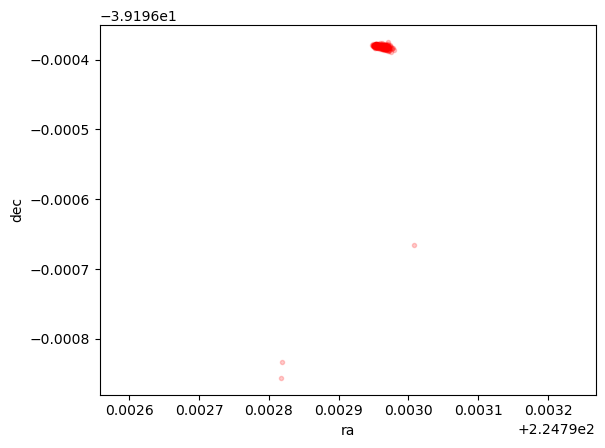

Clipped distribution of points:


/lscratch/mredden/ipykernel_2755523/3947897300.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


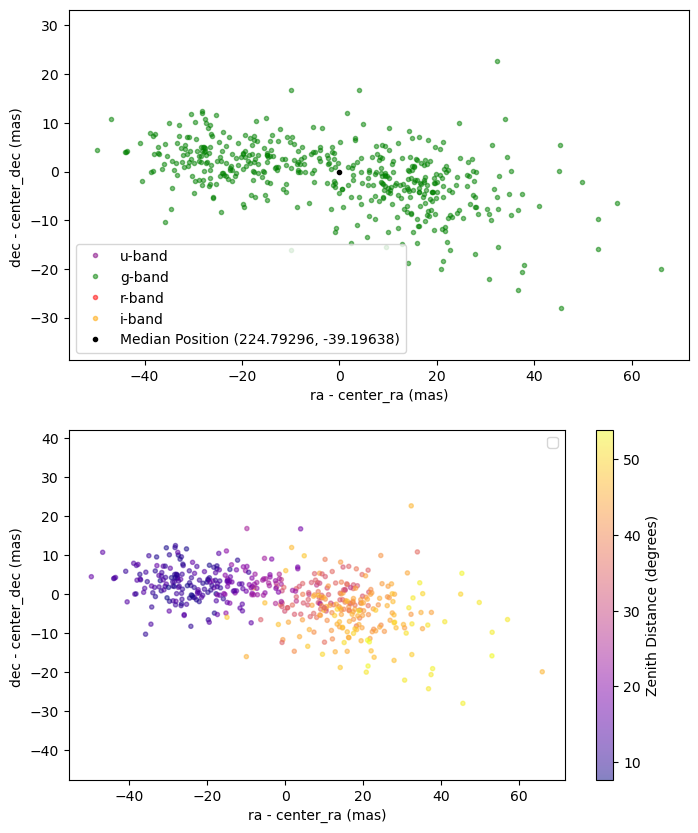

In [112]:
# Plot to check the distribution of visits looks as expected for a single object (limited to a few arcsec)
# If there are outliers, adjust the clipping radius below as needed

# Naive approach for finding true center
center_ra = np.median(master_all['ra'])
center_dec = np.median(master_all['dec'])

print('Median coordinates: ', np.round(center_ra, 8), np.round(center_dec, 8))

plt.plot(master_all['ra'], master_all['dec'], 'r.', alpha = 0.2)
plt.xlabel('ra')
plt.ylabel('dec')
plt.axis('equal')
plt.show()
plt.close()


# create a mask to clip out the outliers:
clipping_radius = 0.00005 # degrees, 0.0001 is ~0.36 arcsec

mask = ((master_all['ra'] - center_ra)**2 + (master_all['dec'] - center_dec)**2) < (clipping_radius)**2
master = master_all[mask]

master_original = master.copy()


# print('Number of points after clipping: ', len(master))
print('Clipped distribution of points:')


scale = 3600 * 1000 #to convert degrees to milliarcseconds for plotting


# Plot the distribution of points, color coded by band and zenith distance
fig, ax = plt.subplots(2,1, figsize=(8, 10))

colors = {'u': 'purple', 'g': 'green', 'r': 'red', 'i': 'orange'}
for band in 'ugri':
    mask = master['band'] == band
    ax[0].plot((master['ra'][mask] - center_ra)*scale, (master['dec'][mask] - center_dec)*scale, '.', alpha = 0.5, label = f'{band}-band', color=colors[band])

# plt.plot(master['ra'], master['dec'], 'r.', alpha = 0.2)
# plt.plot(53.12651507954, -28.31641093456, 'b.', label = "GAIA DR3 Position")
# plt.errorbar((53.21692723831 - center_ra)*scale, (-27.92220192498- center_dec)*scale, xerr = 0.1/3600000 * scale, yerr = 0.1/3600000 * scale, fmt = 'k*', label = "GAIA DR3 Position")
ax[0].plot(0, 0, 'k.', label = f"Median Position ({center_ra:.5f}, {center_dec:.5f})")
ax[0].legend()
ax[0].set_xlabel('ra - center_ra (mas)')
ax[0].set_ylabel('dec - center_dec (mas) ')
ax[0].axis('equal')


mask = (master['band'] == 'u') | (master['band'] == 'g') |(master['band'] == 'r')
sc = plt.scatter((master['ra']- center_ra)[mask]*scale, (master['dec'] - center_dec)[mask]*scale, c=master['zenithDistance'][mask], cmap = 'plasma', alpha = 0.5, marker = '.')
# plt.plot(53.12651507954, -28.31641093456, 'b.', label = "GAIA DR3 Position")
# plt.errorbar((53.21692723831 - center_ra)*scale, (-27.92220192498- center_dec)*scale, xerr = 0.1/3600000 * scale, yerr = 0.1/3600000 * scale, fmt = 'k*', label = "GAIA DR3 Position")
plt.colorbar(sc, label = 'Zenith Distance (degrees)')
# plt.plot(0, 0, 'k.', label = "Median Position")
ax[1].legend()
ax[1].set_xlabel('ra - center_ra (mas)')
ax[1].set_ylabel('dec - center_dec (mas) ')
ax[1].axis('equal')
plt.show()

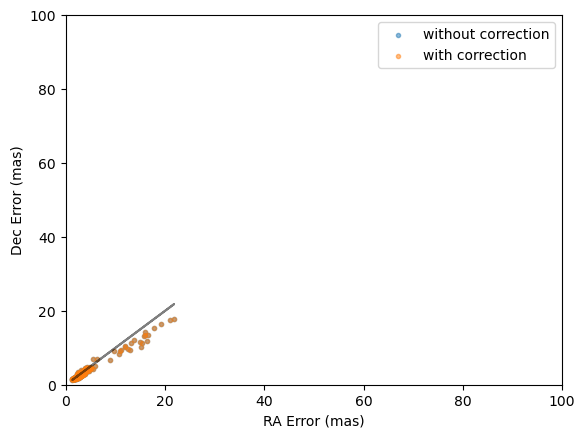

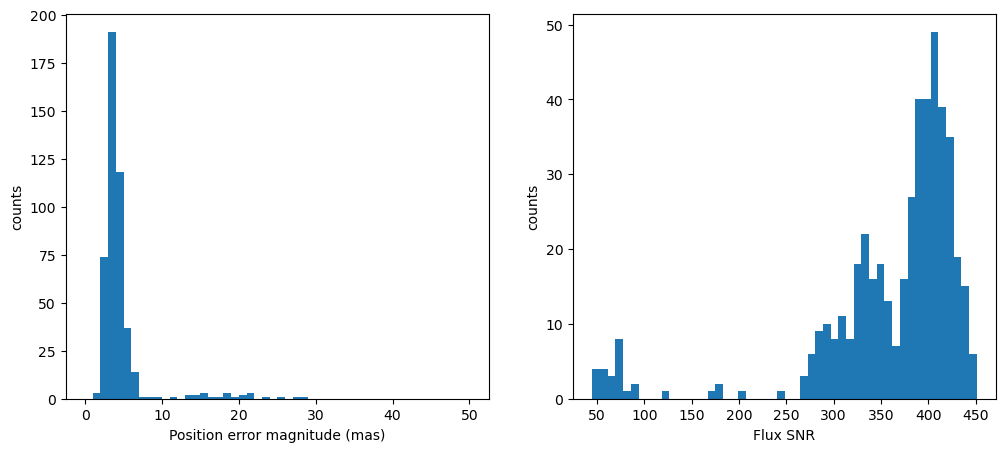

In [113]:
#Apply correction to raErr and ra_dec_Cov to account for overcorrection in DP1 and check data quality
# check distributions of raErr and decErr: (see community forum post for more discussion on this https://community.lsst.org/t/anomalies-in-dp1-right-ascension-errors/11178/13)

correction =  1 #np.cos(master_original['dec']*np.pi/180)

plt.scatter(master_original['raErr'] * 3600 * 10**3, master_original['decErr'] * 3600 * 10**3, alpha = 0.5,marker = '.', label = 'without correction')
plt.scatter(master_original['raErr']/correction * 3600 * 10**3, master_original['decErr'] * 3600 * 10**3, alpha = 0.5,marker = '.',
 label = 'with correction')
plt.plot(master_original['raErr'] * 3600 * 10**3, master_original['raErr'] * 3600 * 10**3, 'k-', alpha = 0.5)
plt.xlabel('RA Error (mas)')
plt.ylabel('Dec Error (mas)')
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend()
plt.show()
plt.close()


#apply correction using master_original to prevent overwriting the already corrected values in master:
master['raErr'] = master_original['raErr'] #/ correction 
master['ra_dec_Cov'] = master_original['ra_dec_Cov'] #/correction


fig, ax = plt.subplots(1,2, figsize = (12, 5))

band_mask = master['band'] == 'g'

ax[0].hist(np.sqrt(master['raErr'][band_mask]**2 + master['decErr'][band_mask]**2)*3600 * 10**3, 50, range = (0, 50)) # magnitude of position error
ax[0].set_xlabel('Position error magnitude (mas)')
ax[0].set_ylabel('counts')

ax[1].hist(master['psfFlux'][band_mask]/master['psfFluxErr'][band_mask], 50) # magnitude of position error
ax[1].set_xlabel('Flux SNR')
ax[1].set_ylabel('counts')

plt.show()


In [114]:
# Add a few columns to the master table: zenith RA/Dec, parallactic angle

# Add zenith coordinates to the master table
master = add_zenith_coordinates(master, lat=lat, lon=lon, height=height)

# Add parallactic angle to the master table
master = parallactic_angle_from_radec_fast(master, lat=lat, lon=lon, height=height, sidereal_kind = 'mean')



--- Warning!! Too few points to properly estimate center. Using median of all points ---
--- Naive Fitting Approach:
Center coord:  (np.float64(224.79296167641593), np.float64(-39.19638093304284))
Center err:  (np.float64(6.108393517625712e-06), np.float64(1.8084735024658327e-06))
g 14.9 +- 0.2
--- Complete Fitting Approach:
Center coord:  (np.float64(224.79295624151757), np.float64(-39.196381248918286))
Center err:  (np.float64(2.030029618189401e-07), np.float64(1.1172788569092091e-07))
g 31.13 +- 0.77
-19.565634079299343 -1.137151608077147


/lscratch/mredden/ipykernel_2755523/2579280085.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dR[i] = dalt


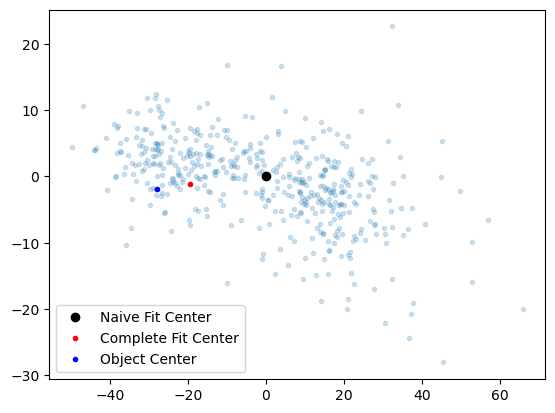

In [115]:
# *** In development ***

# Generate and run a function that takes in the locations of each source and the band,
# and returns the \Delta R_45 for each band AND (optionally) the center location

def compute_dR_and_err(center_ra, center_dec, ra, dec, par, raErr, decErr, ra_dec_Cov):
        '''
        For a given center location, compute projected zenith offset dR and
            propagated uncertainty dR_err.

        '''
    
        dR = np.zeros(len(ra))
        dR_err = np.zeros(len(ra))

        for i in range(len(ra)):
            # Rotation from RA/Dec offsets into azimuth/altitude frame using parallactic angle q.
            cq, sq = np.cos(par[i]), np.sin(par[i])
            rot = np.array([[cq, -sq], [sq, cq]])

            dRA = (ra[i] - center_ra) * np.cos(dec[i] * np.pi / 180) #requires correction due to spherical geometry
            dDec = dec[i] - center_dec
            _, dalt = rot @ np.array([[dRA, dDec]]).T
            dR[i] = dalt

            # Propagate RA/Dec covariance into rotated frame and keep altitude component uncertainty.
            cov_matrix = np.array([[raErr[i]**2, ra_dec_Cov[i]],
                                   [ra_dec_Cov[i], decErr[i]**2]])
            r_err_matrix = rot @ cov_matrix @ rot.T
            dR_err[i] = np.sqrt(np.abs(r_err_matrix[1, 1]))

        # Keep only finite, positive uncertainties for weighted residuals.
        finite_mask = np.isfinite(dR) & np.isfinite(dR_err) & (dR_err > 0)
        return dR, dR_err, finite_mask


def fitDeltaR45_Naive(master, snr_cut=10):
    """Fit per-band R45 using a fixed center estimated from detections.

    Strategy
    --------
    1) Apply SNR cut.
    2) Estimate unrefracted center from median (prefer r/i at low zenith distance).
    3) Compute dR and dR_err for each row.
    4) Fit R45 per band with weighted curve_fit to dR = R45 * tan(z).

    Returns
    -------
    (r45s, r45_errs, center_fit, center_fit_err, n_rows_used)
    """
    if snr_cut is not None:
        snr_mask = master['psfFlux'] / master['psfFluxErr'] >= snr_cut
        master = master[snr_mask]

    if len(master) == 0:
        raise ValueError('No rows available after SNR cut.')

    par = np.array(master['q'])
    ra = np.array(master['ra'])
    dec = np.array(master['dec'])
    ra_err = np.array(master['raErr'])
    dec_err = np.array(master['decErr'])
    ra_dec_cov = np.array(master['ra_dec_Cov'])
    zenith_distance = np.array(master['zenithDistance'])
    band_col = np.array(master['band'])

    # Same center mask strategy as DCR_in_DP1 naive method
    center_mask = ((band_col == 'r') | (band_col == 'i')) & (zenith_distance < 20)
    if np.sum(center_mask) < 40:  # fallback if there are too few center-defining points
        print('--- Warning!! Too few points to properly estimate center. Using median of all points ---')
        center_mask = np.ones(len(master), dtype=bool)

    center_ra = np.median(ra[center_mask])
    center_dec = np.median(dec[center_mask])
    center_ra_err = np.std(ra[center_mask])
    center_dec_err = np.std(dec[center_mask])

    dR, dR_err, finite_mask = compute_dR_and_err(
        center_ra, center_dec, ra, dec, par, ra_err, dec_err, ra_dec_cov
    )

    def dR_model(z, r45):
        return r45 * np.tan(z * np.pi / 180)

    r45s = {}
    r45_errs = {}

    unique_bands = np.unique(band_col)
    for band in unique_bands:
        band_mask = (band_col == band) & finite_mask
        if np.sum(band_mask) < 2:
            continue

        popt, pcov = curve_fit(
            dR_model,
            zenith_distance[band_mask],
            dR[band_mask],
            sigma=dR_err[band_mask],
            p0=[0],
            absolute_sigma=True,
            maxfev=10000,
        )

        r45s[band] = popt[0]
        r45_errs[band] = np.sqrt(np.diag(pcov))[0]

    return r45s, r45_errs, (center_ra, center_dec), (center_ra_err, center_dec_err), len(master)


def fitDeltaR45_Complete(master_, SNR=10):
    master = master_.copy()
    # Use least-squares for a joint fit of center_ra, center_dec, and per-band R45 values.
    from scipy.optimize import least_squares

    # Optional SNR cut to remove low-quality detections before fitting.
    if SNR is not None:
        SNR_mask = master['psfFlux'] / master['psfFluxErr'] >= SNR
        master = master[SNR_mask]

    # Convert table columns to numpy arrays for fast numeric operations.
    par = np.array(master['q'])
    ra = np.array(master['ra'])
    dec = np.array(master['dec'])
    raErr = np.array(master['raErr'])
    decErr = np.array(master['decErr'])
    ra_dec_Cov = np.array(master['ra_dec_Cov'])
    zenith_distance = np.array(master['zenithDistance'])
    band_col = np.array(master['band'])

    # Guard against empty input after cuts.
    if len(master) == 0:
        raise ValueError('No rows available after masking.')

    # Initial center guess and prior widths from the sample distribution.
    center_ra0 = np.median(ra)
    center_dec0 = np.median(dec)
    center_ra_err0 = np.std(ra)/np.sqrt(len(ra))
    center_dec_err0 = np.std(dec)/np.sqrt(len(ra))

    # Avoid zero-width priors, which can cause divide-by-zero in residuals.
    if center_ra_err0 <= 0:
        center_ra_err0 = 1e-8
    if center_dec_err0 <= 0:
        center_dec_err0 = 1e-8

    # Build a compact mapping from band labels to parameter indices.
    unique_bands = np.unique(band_col)
    if len(unique_bands) == 0:
        raise ValueError('No valid bands available for fitting.')

    band_to_index = {band: i for i, band in enumerate(unique_bands)}
    band_index = np.array([band_to_index[band] for band in band_col], dtype=int)

    # Compute dR once at the initial center for robust R45 initialization.
    dR0, dR_err0, finite_mask0 = compute_dR_and_err(center_ra0, center_dec0, ra, dec, par, raErr, decErr, ra_dec_Cov)

    def func(z, R45):
        # Per-band DCR model: dR = R45 * tan(z).
        return R45 * np.tan(z * np.pi / 180)

    # Initialize per-band R45 with independent weighted fits at fixed initial center.
    R45_init = np.zeros(len(unique_bands))
    for j, band in enumerate(unique_bands):
        band_mask = (band_col == band) & finite_mask0
        if np.sum(band_mask) < 2:
            R45_init[j] = 0.0
            continue
        try:
            popt, _ = curve_fit(
                func,
                zenith_distance[band_mask],
                dR0[band_mask],
                sigma=dR_err0[band_mask],
                p0=[0],
                absolute_sigma=True,
                maxfev=10000,
            )
            R45_init[j] = popt[0]
        except Exception:
            # Fallback if a single-band initialization fit fails.
            R45_init[j] = 0.0

    # Parameter vector: [center_ra, center_dec, R45_band0, R45_band1, ...].
    x0 = np.concatenate(([center_ra0, center_dec0], R45_init))

    def residuals(params):
        # Unpack trial parameters.
        center_ra = params[0]
        center_dec = params[1]
        R45_vals = params[2:]

        # Data residuals: (measured dR - model dR)/sigma.
        dR, dR_err, finite_mask = compute_dR_and_err(center_ra, center_dec, ra, dec, par, raErr, decErr, ra_dec_Cov)
        model = R45_vals[band_index] * np.tan(zenith_distance * np.pi / 180)
        data_resid = (dR - model) / dR_err
        data_resid = data_resid[finite_mask]

        # Weak Gaussian priors on center coordinates from the initial guess uncertainties.
        prior_resid = np.array([
            (center_ra - center_ra0) / center_ra_err0,
            (center_dec - center_dec0) / center_dec_err0,
        ])

        # Joint residual vector used by least_squares.
        return np.concatenate((data_resid, prior_resid))

    # Solve the joint nonlinear least-squares problem.
    result = least_squares(residuals, x0, method='trf')

    # Extract best-fit parameters.
    best_params = result.x
    center_ra_fit, center_dec_fit = best_params[0], best_params[1]
    R45_fit = best_params[2:]

    # Estimate parameter covariance from Jacobian (scaled by reduced chi^2).
    n_resid = len(result.fun)
    n_param = len(best_params)
    dof = n_resid - n_param

    if dof > 0 and result.jac.size > 0:
        try:
            jacobian = result.jac
            cov = np.linalg.pinv(jacobian.T @ jacobian)
            chi2_red = 2 * result.cost / dof
            cov = cov * chi2_red
            param_err = np.sqrt(np.clip(np.diag(cov), 0, np.inf))
        except Exception:
            param_err = np.full(n_param, np.nan)
    else:
        param_err = np.full(n_param, np.nan)

    # Split uncertainties into center terms and band terms.
    center_ra_fit_err, center_dec_fit_err = param_err[0], param_err[1]
    R45_fit_err = param_err[2:]

    # Repackage outputs to match the format of fitDeltaR45 for easy comparison.
    R45s = {band: R45_fit[j] for j, band in enumerate(unique_bands)}
    R45_errs = {band: R45_fit_err[j] for j, band in enumerate(unique_bands)}

    return R45s, R45_errs, (center_ra_fit, center_dec_fit), (center_ra_fit_err, center_dec_fit_err)


R45s, R45errs, centerest, centererr, N = fitDeltaR45_Naive(master)
print('--- Naive Fitting Approach:')
print('Center coord: ', centerest)
print('Center err: ', centererr)
for key in 'ugrizy':
    try:
        item = R45s[key]
        print(key, np.round(item * 3600 * 10**3, 2), '+-', np.round( R45errs[key] * 3600 * 10**3, 2))
    except:
        continue

R45s2, R45errs2, centerest2, centererr2 = fitDeltaR45_Complete(master)
print('--- Complete Fitting Approach:')
print('Center coord: ', centerest2)
print('Center err: ', centererr2)
for key in 'ugrizy':
    try:
        item = R45s2[key]
        print(key, np.round(item * 3600 * 10**3, 2), '+-', np.round( R45errs2[key] * 3600 * 10**3, 2))
    except:
        continue

plt.scatter((master['ra'] - centerest[0]) * 3600 * 10**3, (master['dec'] - centerest[1]) * 3600 * 10**3, marker = '.', alpha = 0.2)
plt.plot(0,0, 'ko' , label = 'Naive Fit Center')
plt.plot((centerest2[0] - centerest[0]) * 3600 * 10**3, (centerest2[1] - centerest[1])* 3600 * 10**3, 'r.', label = 'Complete Fit Center')
plt.plot((object_table['coord_ra'] - centerest[0]) * 3600 * 10**3, (object_table['coord_dec'] - centerest[1])* 3600 * 10**3, 'b.', label = 'Object Center')
plt.legend()
# plt.xlim(-5, 5)
# plt.ylim(-5, 5)
print((centerest2[0] - centerest[0]) * 3600 * 10**3, (centerest2[1] - centerest[1])* 3600 * 10**3)

In [116]:
object_table

coord_dec,coord_ra,g_inputCount,detect_fromBlend,detect_isIsolated,g_cModelMag,g_cModelMagErr,g_psfMag,g_psfMagErr,i_cModelMag,i_cModelMagErr,i_psfMag,i_psfMagErr,objectId,parentObjectId,patch,r_cModelMag,r_cModelMagErr,r_psfMag,r_psfMagErr,refBand,refExtendedness,refSizeExtendedness,shape_xx,shape_xy,shape_yy,tract,u_cModelMag,u_cModelMagErr,u_psfMag,u_psfMagErr,y_cModelMag,y_cModelMagErr,y_psfMag,y_psfMagErr,z_cModelMag,z_cModelMagErr,z_psfMag,z_psfMagErr,u_psfFlux,g_psfFlux,r_psfFlux,i_psfFlux,z_psfFlux,y_psfFlux,g_calib_astrometry_used
deg,deg,,,,mag,mag,mag,mag,mag,mag,mag,mag,,,,mag,mag,mag,mag,,,,pix2,pix2,pix2,,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,nJy,nJy,nJy,nJy,nJy,nJy,
float64,float64,int32,bool,bool,float32,float32,float32,float32,float32,float32,float32,float32,int64,int64,int64,float32,float32,float32,float32,str1,float32,float32,float32,float32,float32,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,bool
-39.196381457959795,224.79295386299353,256,True,False,18.5726,0.000165135,18.5723,0.000163435,18.271,0.000192733,18.2701,0.000191793,744858929556629938,744858929556619267,64,18.3369,0.000174371,18.3364,0.0001732,u,0.0,0.000136826,7.54099,-0.167272,7.29651,3533,19.4054,0.000758571,19.406,0.000752095,18.2809,0.00105162,18.279,0.00104671,18.2766,0.00033336,18.2762,0.000331573,62746.3,135235.0,168049.0,178638.0,177636.0,177170.0,True


In [117]:
# Pick a center and calculate the final dR and dR err, add them to the master table

par = np.array(master['q'])
ra = np.array(master['ra'])
dec = np.array(master['dec'])
raErr = np.array(master['raErr'])
decErr = np.array(master['decErr'])
ra_dec_Cov = np.array(master['ra_dec_Cov'])

dR, dR_err, finite_mask = compute_dR_and_err(object_table['coord_ra'][0], object_table['coord_dec'][0],ra, dec, par, raErr, decErr, ra_dec_Cov)
# centerest[0], centerest[1]

master['dR'] = dR
master['dR_err'] = dR_err


/lscratch/mredden/ipykernel_2755523/2579280085.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dR[i] = dalt


In [122]:

from utils import radec_to_altaz_vectorized
ra  = master['ra']
dec = master['dec']
MJD = master['expMidptMJD']
alt, az = radec_to_altaz_vectorized(ra, dec, MJD) #calculate the correct alt/az (the queried values are for the boresight)
master['Z'] = 90 - alt # - alt
master['az'] = az # - az


<>:177: SyntaxWarning: invalid escape sequence '\D'
<>:177: SyntaxWarning: invalid escape sequence '\D'
/lscratch/mredden/ipykernel_2755523/4179772318.py:177: SyntaxWarning: invalid escape sequence '\D'
  print('expected \Delta R_45: ', sim_dRs[band]*1e3)


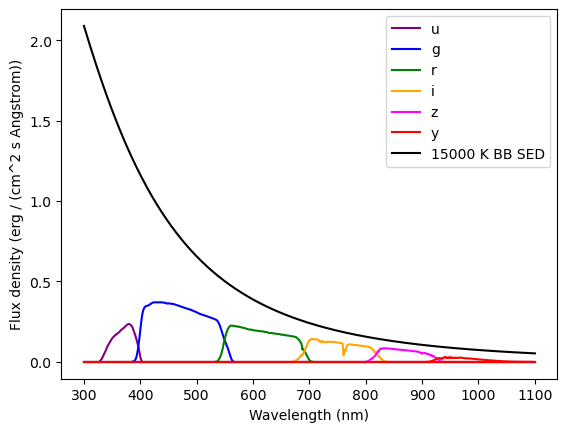

g-r color of source:  -0.3715
Mean wavelength direct calc:  369.4189141370029
Mean wavelength direct calc:  470.1292737569148
0.03833805224526427 0.0004508566567575347
Estimated wavelength for band g: 476.91 nm (+ 0.11 / - 0.11)
expected \Delta R_45:  63.32885725344318
Simulated BB estimated wavelength for band {band}:  470.83  nm


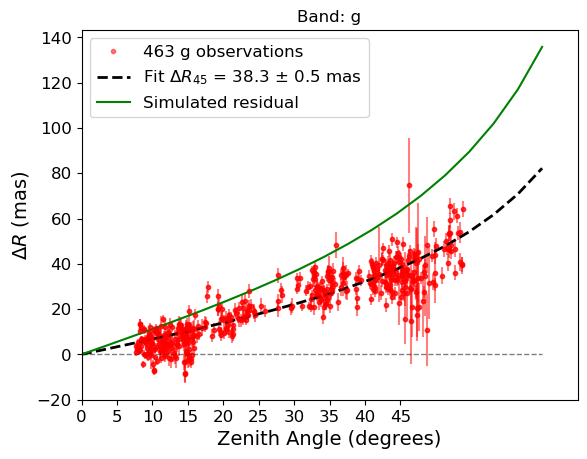

Mean wavelength direct calc:  613.7538073756862
Mean wavelength direct calc:  749.5222208926943
Mean wavelength direct calc:  864.3510889694875
Mean wavelength direct calc:  971.6594584767954


In [123]:
# Generate a model of the expected DCR for black bodys (if the temperatures are approximately known)
# The model uses a blackbody SED of a specified temperature as the source, and a second blackbody SED of a different temperature as the reference
# Plot the residuals in each band with a best-fit model and the expected model



def dR_model(z, c):
    return c * np.tan(z * np.pi/180)


# Define the source and reference temperatures:
source_temperature = 15000 #K
reference_temperature = 5000 #K


wavelengths = np.linspace(300, 1100, 1000) # nm 


h  = 6.62607015e-27       # erg s
c  = 2.99792458e17        # nm / s
hc = h * c                # erg nm (≈ 1.986e-9)
NJY  = 1e-32                            # erg/s/cm^2/Hz per nJy

 
# Set up the source and reference SED as galsim SED objects:

BBsrc = BB(wavelengths, source_temperature, 1e-9) # flam units
table_src = galsim.LookupTable(wavelengths*10, BBsrc  * wavelengths /hc, interpolant = 'linear') # convert wavelengths to Angstroms
sed_src = galsim.SED(table_src, wave_type = 'A', flux_type = 'fphotons')

# C26202 SED:
# from astropy.io import fits
# hdul = fits.open("scrap/c26202_stiswfcnic_008.fits")
# # print(hdul[1].header)
# wave = hdul[1].data['WAVELENGTH'] #* u.AA
# flux = hdul[1].data['FLUX'] #* u.erg / u.s / u.cm**2 / u.AA
# flux = interp1d(wave, flux)(wavelengths * 10)
# flux = flux #/ np.mean(flux)

# plt.plot(wavelengths, flux )

# table_src = galsim.LookupTable(wavelengths * 10, flux, interpolant = 'linear') # convert wavelengths to Angstroms
# sed_src = galsim.SED(table_src, wave_type = 'A', flux_type = 'flambda')



BBref = BB(wavelengths, reference_temperature, 1e-7) # flam units
table_ref = galsim.LookupTable(wavelengths*10, BBref  * wavelengths  /hc, interpolant = 'linear') # convert wavelengths to Angstroms
sed_ref = galsim.SED(table_ref, wave_type = 'A', flux_type = 'fphotons')


# Calculate flux, the first moment (dR) and second moment (dVar) shifts at 45 degrees for each band of the src - ref

#Matthew's atmospheric conditions
pressure=70.0,  # kPa
temperature=293.15,  # K
H2O_pressure=0.0,

#Pat and Josh's paper atmospheric conditions 
pressure=69.328
temperature=293.15
H2O_pressure=1.067

Flux_src = {}
Flux_ref = {}

sim_dRs = {}
sim_dVars = {}

band_edges = {'u': [334., 400.], 'g': [395., 560.], 'r': [542., 699.], 'i': [680., 831.], 'z' :[807., 931.], 'y' :[ 916., 1054.]}
pivots = {'u': 371.0, 'g': 479.0, 'r': 621.0, 'i': 755.0, 'z': 867.0, 'y': 975.0}

colors = {'u' : 'purple', 'g':'blue', 'r': 'green', 'i': 'orange', 'z' : 'magenta', 'y' : 'red'}

for band in 'ugrizy':

    bandpass = filters[band]

    
    Flux_src[band] = sed_src.calculateFlux(bandpass)

    R, V = sed_src.calculateDCRMomentShifts(
        bandpass,
        zenith_angle = 45 * galsim.degrees,
        parallactic_angle = 0 * galsim.degrees,
        pressure = pressure,
        temperature = temperature,
        H2O_pressure = H2O_pressure) 

    
    Flux_ref[band] = sed_ref.calculateFlux(bandpass)

    R_ref, V_ref = sed_ref.calculateDCRMomentShifts(
        bandpass,
        zenith_angle = 45 * galsim.degrees,
        parallactic_angle = 0 * galsim.degrees,
        pressure = pressure,
        temperature = temperature,
        H2O_pressure = H2O_pressure) 

    
    sim_dRs[band] = (R[-1] - R_ref[-1]) * (180 * 3600 / np.pi) # arcsec
    sim_dVars[band] = (V[-1,-1] - V_ref[-1,-1]) * (180 * 3600 / np.pi)**2  #arcsec^2

    # plot the filtered src SED:

    plt.plot(sed_src.__mul__(bandpass).wave_list, sed_src.__mul__(bandpass)(sed_src.__mul__(bandpass).wave_list) * hc/sed_src.__mul__(bandpass).wave_list, label = f'{band}', color = colors[band])

    measured_flux = np.zeros(len(wavelengths))
    band_mask = (wavelengths > band_edges[band][0]) * (wavelengths < band_edges[band][1])
    measured_flux[band_mask] = measured_flux[band_mask] + (object_table[f'{band}_psfFlux'] * NJY * c / pivots[band]**2)# * 10**15)
    plt.plot(wavelengths, measured_flux, '-', color = colors[band])




# seds = [BBsrc, BBref,  np.ones(len(wavelengths))*np.max(BBsrc)*0.1]

# Plot the model SEDs
plt.plot(sed_src.wave_list, sed_src(sed_src.wave_list) * hc/sed_src.wave_list , 'k-', label = f'{source_temperature} K BB SED')
# plt.plot(sed_ref.wave_list, sed_ref(sed_ref.wave_list) * hc/sed_ref.wave_list , 'k--', label = f'{reference_temperature} K BB SED')


plt.legend()
plt.xlabel('Wavelength (nm)')
plt.ylabel('Flux density (erg / (cm^2 s Angstrom))')
plt.show()
plt.close()

gr_color = -2.5 * np.log10(Flux_src['g'] / Flux_src['r'])
print('g-r color of source: ', np.round(gr_color, 4))

from wavelength_estimate import generate_templates, estimate_mean_wave
templates = generate_templates(reference_temperature = 4500, sigma = 100, gaussian = False)



# Plot the model results on top of the data

bf_wl = {}
bf_wl_errs= {}
for band in 'ugrizy':
    band_mask = master['band'] == band


    #add another band mask to throw out large errors
    error_mask = master['dR_err']<  100 / ( 3600 * 10**3)# degrees
    band_mask = band_mask & error_mask

    bandpass = filters[band]
    x, y = sed_src.__mul__(bandpass).wave_list, sed_src.__mul__(bandpass)(sed_src.__mul__(bandpass).wave_list) * hc/sed_src.__mul__(bandpass).wave_list
    mean_wave = np.trapezoid(x = x, y = x * y) / np.trapezoid(x = x, y = y)
    print('Mean wavelength direct calc: ', mean_wave)


    if np.sum(band_mask) > 0:

        
        airmass = master[band_mask]['airmass']
        z = np.arccos(1 / airmass) * 180 / np.pi
        tanz = np.tan(z * np.pi/180)

        dR = master['dR'][band_mask] #master['r_temp'][band_mask]
        dR_err =master['dR_err'][band_mask] # + 5 / (3600 * 10**3) #master['r_err'][band_mask]

        popt, pcov = curve_fit(dR_model, z, dR, sigma = dR_err, p0 = [0])
        perr = np.sqrt(np.diag(pcov))
        print(popt[0]*3600, perr[0]*3600)

        wave_max, wave_mean, wave_min = estimate_mean_wave(np.array([popt[0] - perr[0], popt[0], popt[0] + perr[0]])*3600, band, *templates)
        print(f'Estimated wavelength for band {band}: {np.round(wave_mean, 2)} nm (+ {np.round(wave_max - wave_mean, 2)} / - {np.round(wave_mean - wave_min, 2)})')
        bf_wl[band] = wave_mean
        bf_wl_errs[band] = np.max([wave_max - wave_mean, wave_mean - wave_min])
        
        # print('BB estimated wavelength for band {band}: ', np.round(BB_mean_wavelengths[band][0], 2)/10, ' nm')
        # print('BB reference wavelength for band {band}: ', np.round(BB_mean_wavelengths[band][1], 2)/10, ' nm')
        print('expected \Delta R_45: ', sim_dRs[band]*1e3)
        wave_sim = estimate_mean_wave(np.array([sim_dRs[band]]), band, *templates)[0]
        print('Simulated BB estimated wavelength for band {band}: ', np.round(wave_sim, 2), ' nm')


        plt.plot(z, dR * 3600 * 10**3,  ls = '', marker = '.', alpha = 0.5, color = 'r', label = f'{len(dR)} {band} observations') #label = f'Source:  {np.round(center_ra, 4)}, {np.round(center_dec, 4)}')
        plt.errorbar(z, dR * 3600 * 10**3, yerr = dR_err * 3600 * 10**3, ls = '', marker = '.', alpha = 0.5, color = 'r')
        
        z_temp = np.linspace(0, 65, 20) 
        tanz_temp = np.tan(z_temp * np.pi/180)
        plt.plot(z_temp, dR_model(z_temp, *popt) * 3600 * 10**3, 'k--', linewidth = 2, label = rf'Fit $\Delta R_{{45}}$ = {np.round(popt[0]*3600*1000, 1)} $\pm$ {np.round(perr[0]*3600*1000, 1)} mas')#'Trendline: A tan(z)')
        plt.plot(z_temp, np.zeros(len(z_temp)) * 3600 * 10**3, 'k--', alpha = 0.5, linewidth = 1) #, label = 'Flat')
        plt.plot(z_temp, dR_model(z_temp, sim_dRs[band]) * 10**3 , 'g-', label = f'Simulated residual') #{source_temperature} K star (reference: {reference_temperature} K star)')
        
        plt.title(f'Band: {band}')
        plt.xlabel('Zenith Angle (degrees)', fontsize = 14)
        plt.ylabel(r'$\Delta R$ (mas)', fontsize = 14)
        plt.legend(fontsize = 12)
        plt.xlim(0, 70)
        # plt.xlim(0, 1.1)
        plt.tick_params(axis='both', which='major', labelsize=12)
        
        plt.xticks([0, 5, 10,15, 20, 25, 30, 35, 40, 45])

        # plt.savefig(f'scrap/dp1_dcr_model_fit_{band}.pdf')

        plt.show()
        plt.close()


8.974274758263605e-14


KeyError: 'u'

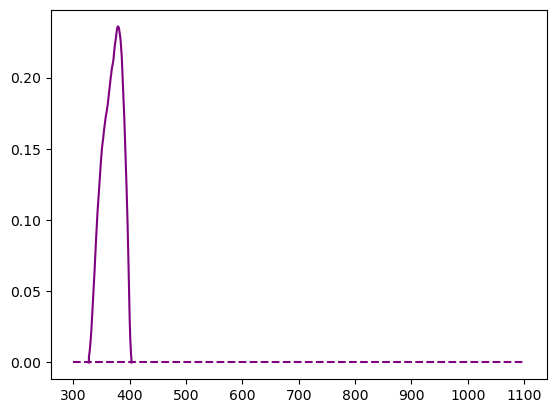

In [124]:

band_edges = {'u': [334., 400.], 'g': [395., 560.], 'r': [542., 699.], 'i': [680., 831.], 'z' :[807., 931.], 'y' :[ 916., 1054.]}
pivots = {'u': 371.0, 'g': 479.0, 'r': 621.0, 'i': 755.0, 'z': 867.0, 'y': 975.0}

colors = {'u' : 'purple', 'g':'blue', 'r': 'green', 'i': 'orange', 'z' : 'magenta', 'y' : 'red'}

for band in 'ugrizy':

    bandpass = filters[band]

    # plot the filtered src SED:

    plt.plot(sed_src.__mul__(bandpass).wave_list, sed_src.__mul__(bandpass)(sed_src.__mul__(bandpass).wave_list) * hc/sed_src.__mul__(bandpass).wave_list, label = f'{band}', color = colors[band])

    measured_flux = np.zeros(len(wavelengths))
    band_mask = (wavelengths > band_edges[band][0]) * (wavelengths < band_edges[band][1])
    measured_flux[band_mask] = measured_flux[band_mask] + (object_table[f'{band}_psfFlux'] * NJY * c / pivots[band]**2)# * 10**15)
    plt.plot(wavelengths, measured_flux, '--', color = colors[band])

    # refined SED with DCR measurements

    T = np.trapezoid(x = wavelengths,y = measured_flux)
    print(T)
    mask1 = (wavelengths < bf_wl[band]) * (wavelengths > band_edges[band][0])
    f1 = T/(2*(bf_wl[band] - band_edges[band][0]))
    measured_flux[mask1] = measured_flux[mask1]*0 + f1
    
    mask2 = (wavelengths > bf_wl[band]) * (wavelengths < band_edges[band][1])
    f2 = T/(2*(band_edges[band][1] - bf_wl[band]))
    measured_flux[mask2] = measured_flux[mask2]*0 + f2
    
    plt.plot(bf_wl[band], 0, 'ko')
    plt.plot(wavelengths, measured_flux, '-', color = colors[band])
    print(bf_wl_errs[band])




# Plot the model SEDs
plt.plot(sed_src.wave_list, sed_src(sed_src.wave_list) * hc/sed_src.wave_list , 'k-', alpha = 0.5, label = f'{source_temperature} K BB SED')
# plt.plot(sed_ref.wave_list, sed_ref(sed_ref.wave_list) * hc/sed_ref.wave_list , 'k--', label = f'{reference_temperature} K BB SED')


plt.legend()
plt.xlabel('Wavelength (nm)')
plt.ylabel('Flux density (erg / (cm^2 s Angstrom))')
plt.show()
plt.close()


<>:53: SyntaxWarning: invalid escape sequence '\D'
<>:53: SyntaxWarning: invalid escape sequence '\D'
/lscratch/mredden/ipykernel_2755523/3600575538.py:53: SyntaxWarning: invalid escape sequence '\D'
  ax[n,m].plot(z_temp_, dR_model(z_temp, sim_dRs[band]) * 10**3 , 'g-', label = f'Expected: $\Delta R_{{45}}$ = {np.round(sim_dRs[band]*1e3, 1)} mas') #{source_temperature} K star (reference: {reference_temperature} K star)')


0.03828412271740514 0.00043747347263007355


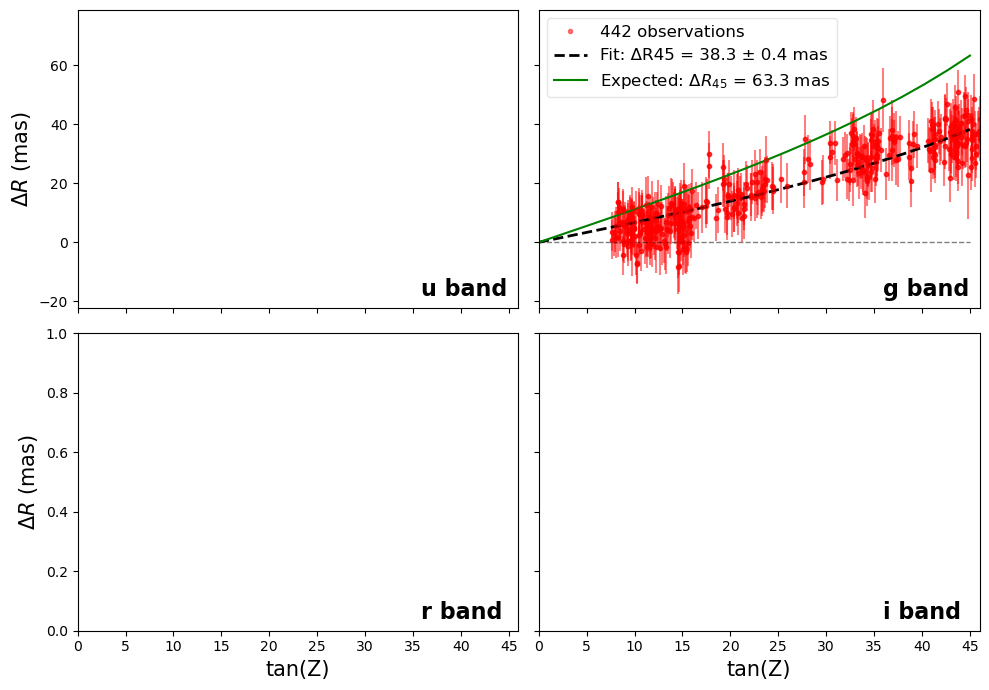

In [ ]:
# Plot in a grid for publishing 


def plotGrid(band_, r_, r_err_, airmass_, savefigloc = None):
    

    def dR_model2(z, R, c):
        return R * np.tan(z * np.pi/180) + c

    fig, ax = plt.subplots(2, 2, figsize=(10,7), sharey = 'row', sharex = True)

    for i, band in enumerate('ugri'):
        # band_mask = master['band'] == band
        band_mask = band_ == band

        #add another band mask to throw out large errors
        # error_mask = master['r_err']<  200 / ( 3600 * 10**3)# degrees
        error_mask = r_err_ <  10 / ( 3600 * 10**3)# degrees
        band_mask = band_mask & error_mask
        

        if np.sum(band_mask) > 0:
            
            # airmass = master[band_mask]['airmass']
            airmass = airmass_[band_mask]
            z = np.arccos(1 / airmass) * 180 / np.pi

            z_ = z #np.tan(z * np.pi/180) #fit in tan(z) space since that is the expected functional form of the DCR effect
            # zeniths_ = zeniths #np.tan(zeniths * np.pi/180)
            
            # dR = master['r_temp'][band_mask]
            # dR_err = master['r_err'][band_mask]
            dR = r_[band_mask]
            dR_err = r_err_[band_mask] + 5/(3600 * 10**3)

            popt, pcov = curve_fit(dR_model, z, dR, sigma = dR_err, p0 = [0 / (3600 * 10**3)]) #, 0])
            perr = np.sqrt(np.diag(pcov))
            print(popt[0]*3600, perr[0]*3600)

            n = i // 2
            m = i % 2



            ax[n,m].plot(z_, dR * 3600 * 10**3,  ls = '', marker = '.', alpha = 0.5, color = 'r', label = f'{len(dR)} observations') #label = f'Source:  {np.round(center_ra, 4)}, {np.round(center_dec, 4)}')
            ax[n,m].errorbar(z_, dR * 3600 * 10**3, yerr = dR_err * 3600 * 10**3, ls = '', marker = '.', alpha = 0.5, color = 'r')
            z_temp = np.linspace(0, 45, 20) 
            z_temp_ = z_temp #np.tan(z_temp * np.pi/180)

            ax[n,m].plot(z_temp_, dR_model(z_temp, *popt) * 3600 * 10**3, 'k--', linewidth = 2, label = rf'Fit: ΔR45 = {np.round(popt[0]*3600*1000, 1)} ± {np.round(perr[0]*3600*1000, 1)} mas')#'Trendline: A tan(z)')
            # ax[n,m].plot(z_temp_, dR_model(z_temp, *popt) * 3600 * 10**3, 'k--', linewidth = 2, label = rf'Fit: Intercept = {np.round(popt[1]*3600*1000, 1)} ± {np.round(perr[1]*3600*1000, 1)} mas')#'Trendline: A tan(z)')
            ax[n,m].plot(z_temp_, np.zeros(len(z_temp_)) * 3600 * 10**3, 'k--', alpha = 0.5, linewidth = 1) #, label = 'Flat')
            ax[n,m].plot(z_temp_, dR_model(z_temp, sim_dRs[band]) * 10**3 , 'g-', label = f'Expected: $\Delta R_{{45}}$ = {np.round(sim_dRs[band]*1e3, 1)} mas') #{source_temperature} K star (reference: {reference_temperature} K star)')
            # ax[n,m].set_title(f'Band: {band}', fontsize = 16)
            # ax[n,m].set_xlabel('Zenith Angle (Degrees)', fontsize = 12)
            # ax[n,m].set_ylabel(r'ΔR (mas)', fontsize = 12)
            ax[n,m].set_xlim(0, 46)
            ax[n,m].legend(loc = 'upper left',fontsize = 12, framealpha = 0.5)
            ax[n,m].tick_params(axis='both', which='major', labelsize=12)
            ax[n,m].set_xticks([0, 5, 10,15, 20, 25, 30, 35, 40, 45])

            # plt.savefig(f'scrap/dp1_dcr_model_fit_{band}.pdf')

            # plt.show()
            # plt.close()

    fig.subplots_adjust(wspace=0) 
    
    # ax[0].set_ylabel(r'ΔR (mas)', fontsize = 15)\
    # ax[0].set_xlabel('Zenith Angle (degrees)', fontsize = 15)
    # ax[1].set_xlabel('Zenith Angle (degrees)', fontsize = 15)
    
    ax[0,0].set_ylabel(r'$\Delta R$ (mas)', fontsize = 15)
    ax[1,0].set_ylabel(r'$\Delta R$ (mas)', fontsize = 15)
    ax[1,0].set_xlabel('tan(Z)', fontsize = 15)
    ax[1,1].set_xlabel('tan(Z)', fontsize = 15)
    plt.tight_layout()

    # ax[0].text(0.78, 1 - 0.9, 'u band', transform=ax[0].transAxes, fontsize=16, fontweight='bold', va='top')
    # ax[1].text(0.78, 1 - 0.9, 'g band', transform=ax[1].transAxes, fontsize=16, fontweight='bold', va='top')
    
    ax[0,0].text(0.78, 1 - 0.9, 'u band', transform=ax[0,0].transAxes, fontsize=16, fontweight='bold', va='top')
    ax[0,1].text(0.78, 1 - 0.9, 'g band', transform=ax[0,1].transAxes, fontsize=16, fontweight='bold', va='top')
    ax[1,0].text(0.78, 1 - 0.9, 'r band', transform=ax[1,0].transAxes, fontsize=16, fontweight='bold', va='top')
    ax[1,1].text(0.78, 1 - 0.9, 'i band', transform=ax[1,1].transAxes, fontsize=16, fontweight='bold', va='top')

    

    if savefigloc is not None:
      fig.savefig(savefigloc)

# plotGrid(master['band'], master['r_temp'], master['r_err'], master['airmass'])


plotGrid(master['band'], master['dR'], master['dR_err'], master['airmass']) #, savefigloc = 'scrap/SiemannPropFigure.pdf')
# plotGrid(master['band'], master['r_temp'], master['r_err'], master['airmass'])

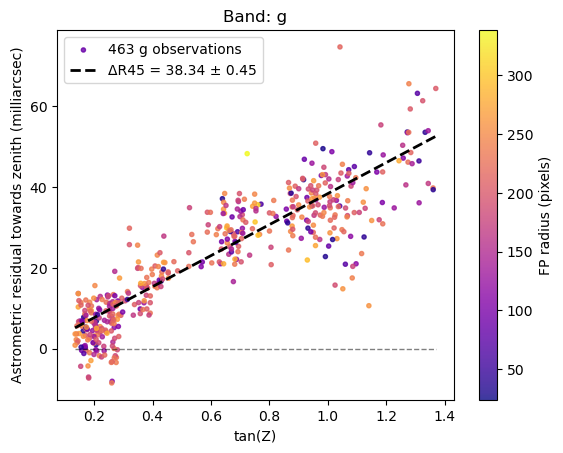

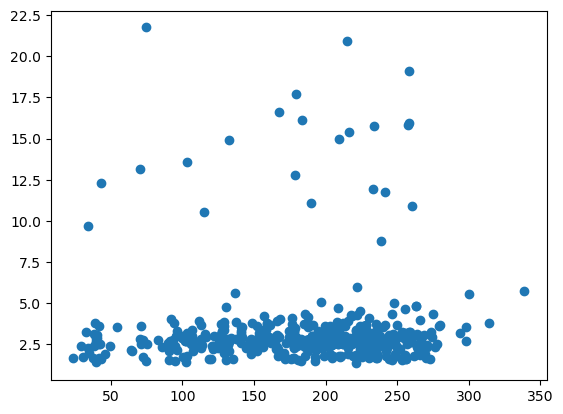

In [126]:
# Plot the residuals along the zenith direction vs zenith angle, for each band
# Also plot a trendline of the form A*tan(z)

def dR_model(z, c):
    return c * np.tan(z * np.pi/180)

for band in 'g':
    band_mask = master['band'] == band

    #Optional: add another mask to throw out large errors
    error_mask = master['dR_err'] <  100 / ( 3600 * 10**3)# degrees
    band_mask = band_mask & error_mask

    if np.sum(band_mask) > 0:

        colormap = master['fp_radius'][band_mask]

        airmass = master[band_mask]['airmass']
        z = np.arccos(1 / airmass) * 180 / np.pi
        tanZ = np.tan(z * np.pi/180)
        
        dR = master['dR'][band_mask]
        dR_err = master['dR_err'][band_mask]

        popt, pcov = curve_fit(dR_model, z, dR, sigma = dR_err, p0 = [0])
        perr = np.sqrt(np.diag(pcov))
        
        #plot dR in milliarcsec as a function of tan(zenith angle)
        sc = plt.scatter(tanZ, dR * 3600 * 10**3,  ls = '', marker = '.', alpha = 0.8, c = colormap, cmap = 'plasma', label = f'{len(dR)} {band} observations')
        # plt.errorbar(tanZ, dR * 3600 * 10**3, yerr = dR_err * 3600 * 10**3, ls = '', marker = '', alpha = 0.5, color = 'r')
        
        #plot a trendline
        z_temp = np.linspace(min(z), max(z), 20) 
        tanZ_temp = np.tan(z_temp * np.pi/180)
        plt.plot(tanZ_temp, dR_model(z_temp, *popt) * 3600 * 10**3, 'k--', linewidth = 2, label = rf'ΔR45 = {np.round(popt[0]*3600*1000, 2)} ± {np.round(perr[0]*3600*1000, 2)}') #label = 'Trendline: A tan(z)')

        plt.plot(tanZ_temp, np.zeros(len(z_temp)) * 3600 * 10**3, 'k--', alpha = 0.5, linewidth = 1) #, label = 'Flat')

        plt.colorbar(sc, label = 'FP radius (pixels)')
        plt.title(f'Band: {band}')
        plt.xlabel('tan(Z)')
        plt.ylabel('Astrometric residual towards zenith (milliarcsec)')
        plt.legend()
        plt.show()
        plt.close()


        plt.scatter(colormap, dR_err * 3600 * 10**3)



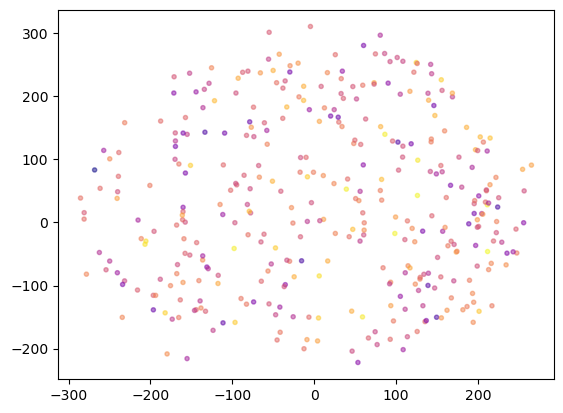

In [ ]:
plt.scatter(master['fp_x'], master['fp_y'], c = master['dR'] * 3600 * 10**3, cmap = 'plasma', marker = '.', alpha = 0.5)

In [ ]:
# master.write('usdf/data_shrtct/data/1st_moments/master_SV225_bluestar.ecsv', overwrite = True)


In [128]:
object_table['g_psfMag'] - object_table['i_psfMag']

0.30220032
